In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print ("✅ pandas:", pd.__version__)
print ("✅ numpy:", np.__version__)
print ("✅ seabon:", sns.__version__)
print ("Ready to start EDA")

✅ pandas: 2.3.2
✅ numpy: 2.3.3
✅ seabon: 0.13.2
Ready to start EDA


In [2]:
# Load Dataset
df_train = pd.read_csv('/Volumes/TimeMachineSSD/mental-health-ai/data/mental_heath_unbanlanced.csv')
df_test = pd.read_csv('/Volumes/TimeMachineSSD/mental-health-ai/data/mental_health_combined_test.csv')

# Display first 5 rows
df_train.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
# Check shape of datasets
print ("Training set shape:", df_train.shape)
print ("Test set shape:", df_test.shape)

# Check colums names
print ("\nTraining colums:", df_train.columns.tolist())
print ("Test colums:", df_test.columns.tolist())

#Check data types
print ("\nData types:")
print (df_train.dtypes)

Training set shape: (49612, 3)
Test set shape: (992, 2)

Training colums: ['Unique_ID', 'text', 'status']
Test colums: ['text', 'status']

Data types:
Unique_ID    float64
text          object
status        object
dtype: object


In [4]:
# Check missing values
print ("Missing values in training set:")
print (df_train.isnull().sum())

print ("\nMissing values in test set:")
print (df_test.isnull().sum())

# Drop missing values if any
df_train = df_train.dropna()
df_test = df_test.dropna()

print ("\nAfter dropping nulls:")
print ("Training set:", df_train.shape)
print ("Test set:", df_test.shape)

Missing values in training set:
Unique_ID    9600
text            0
status          0
dtype: int64

Missing values in test set:
text      0
status    0
dtype: int64

After dropping nulls:
Training set: (40012, 3)
Test set: (992, 2)


Class distribution in training set:
status
Normal        15991
Depression    12106
Suicidal       8812
Anxiety        3103
Name: count, dtype: int64

Percentage:
status
Normal        40.0
Depression    30.3
Suicidal      22.0
Anxiety        7.8
Name: proportion, dtype: float64


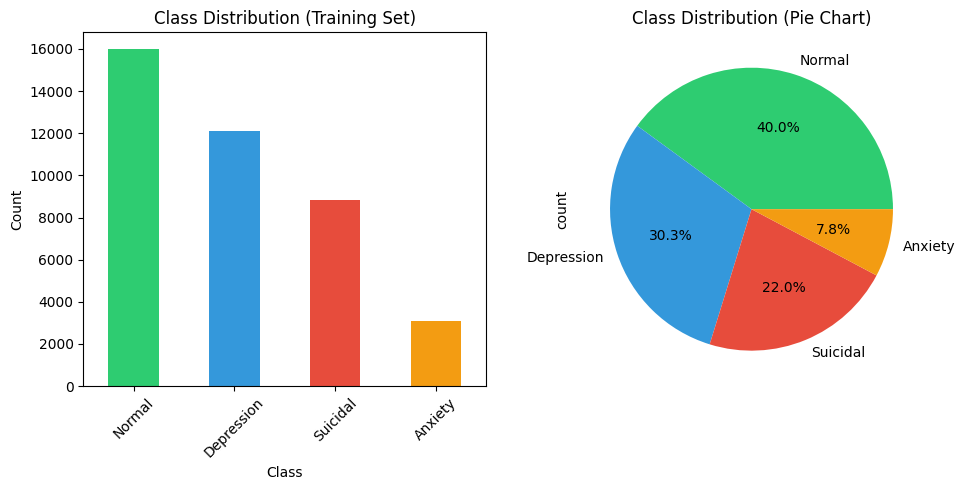

In [6]:
# Check class distribution
print ("Class distribution in training set:")
print (df_train['status'].value_counts())
print ("\nPercentage:")
print (df_train['status'].value_counts(normalize = True).round(3) * 100)

# Visualize class distribution
plt.figure (figsize = (10, 5))

plt.subplot (1, 2, 1)
df_train ['status'].value_counts().plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
plt.title ('Class Distribution (Training Set)')
plt.xlabel ('Class')
plt.ylabel ('Count')
plt.xticks (rotation = 45)

plt.subplot (1, 2, 2)
df_train ['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71','#3498db','#e74c3c','#f39c12'])
plt.title ('Class Distribution (Pie Chart)')

plt.tight_layout()
plt.savefig('../data/class_distribution.png')
plt.show()

Text length statistics:
              count        mean         std   min    25%    50%    75%     max
status                                                                        
Anxiety      3103.0  460.244602  328.000707  10.0  167.0  414.0  712.0  1200.0
Depression  12106.0  483.811085  313.104390  10.0  224.0  425.0  716.0  1200.0
Normal      15991.0   91.893315  120.721864  10.0   29.0   51.0   97.0  1085.0
Suicidal     8812.0  426.994439  305.927692  10.0  169.0  352.5  626.0  1200.0


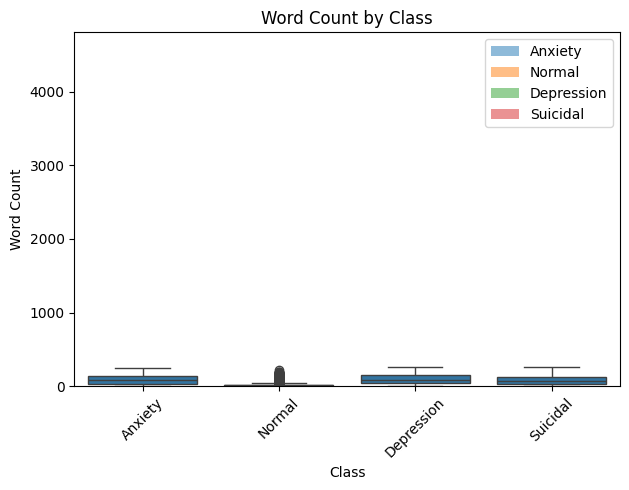

In [8]:
#Add Text length columns
df_train['text_length'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

# Summary statistics
print ("Text length statistics:")
print (df_train.groupby('status')['text_length'].describe())

# Visualize text length by class
plt.figure(figsize = (12, 5))

plt.subplot (1, 2, 2)
for status in df_train['status'].unique():
    subset = df_train[df_train['status'] == status]['text_length']
    plt.hist(subset, alpha=0.5, label=status, bins=50)
plt.title ('Text Length Distribution by Class')
plt.xlabel ('Text Length (characters)')
plt.ylabel ('Count')
plt.legend()

plt.subplot (1, 2, 2)
sns.boxplot (data = df_train, x='status', y='word_count')
plt.title ('Word Count by Class')
plt.xlabel ('Class')
plt.ylabel ('Word Count')
plt.xticks (rotation = 45)

plt.tight_layout()
plt.savefig('../data/text_length_analysis.png')
plt.show()

In [10]:
# Check duplicates
print ("Duplicates in training set:", df_train.duplicated().sum())
print ("Duplicates in test set:", df_test.duplicated().sum())

# Remove duplicates
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

print ("\nAfter removing duplicates:")
print ("Training set:", df_train.shape)
print ("Test set:", df_test.shape)

# Clean text function
import re

def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply cleaning
df_train['clean_text'] = df_train['text'].apply(clean_text)
df_test['clean_text'] = df_test['text'].apply(clean_text)

print ("\nOriginal text:")
print (df_train['text'].iloc[0])
print("\nCleaned text:")
print (df_train['clean_text'].iloc[0])

Duplicates in training set: 0
Duplicates in test set: 0

After removing duplicates:
Training set: (40012, 5)
Test set: (992, 2)

Original text:
oh my gosh

Cleaned text:
oh my gosh


In [11]:
# Encode laabels to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['status'])
df_test['label'] = le.transform(df_test['status'])

# Show mapping
print ("label mapping:")
for i, class_name in enumerate(le.classes_):
    print(f" {class_name} -> {i}")

# Check result
print ("\nSample data:")
print (df_train[['text', 'status', 'label']].head())

label mapping:
 Anxiety -> 0
 Depression -> 1
 Normal -> 2
 Suicidal -> 3

Sample data:
                                                text   status  label
0                                         oh my gosh  Anxiety      0
1  trouble sleeping, confused mind, restless hear...  Anxiety      0
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety      0
3  I've shifted my focus to something else but I'...  Anxiety      0
4  I'm restless and restless, it's been a month n...  Anxiety      0


In [12]:
# Save cleaned datasets
df_train.to_csv('../data/train_cleaned.csv', index=False)
df_test.to_csv('../data/test_cleaned.csv', index=False)

print("✅ Saved train_cleaned.csv")
print("✅ Saved test_cleaned.csv")
print("\nFinal dataset summary:")
print(f"Training set: {df_train.shape[0]:,} rows")
print(f"Test set: {df_test.shape[0]:,} rows")
print(f"\nClass distribution:")
print(df_train['status'].value_counts())

✅ Saved train_cleaned.csv
✅ Saved test_cleaned.csv

Final dataset summary:
Training set: 40,012 rows
Test set: 992 rows

Class distribution:
status
Normal        15991
Depression    12106
Suicidal       8812
Anxiety        3103
Name: count, dtype: int64
